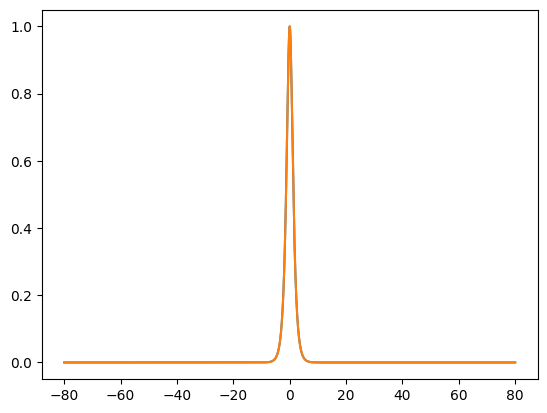

In [2]:
import numpy as np
import matplotlib.pyplot as plt

tau = np.linspace(-80, 80, 4096)
xi_max = 10 * np.pi / 2


def test_cases(N):
    if N == 1:
        return lambda xi: 1 / np.cosh(tau) * np.exp(1j * xi / 2)
    elif N == 2:
        return lambda xi: 4 * np.exp(1j * xi / 2) * ( np.cosh(3 * tau) + 3 * np.exp(4j * xi) * np.cosh(tau) ) / ( np.cosh(4 * tau) + 4 * np.cosh(2 * tau) + 3 * np.cos(4 * xi) )
    else:
        raise NotImplementedError

plt.plot(tau, np.abs(test_cases(1)(xi_max) / 1))
plt.plot(tau, np.abs(test_cases(2)(xi_max) / 2))

\begin{equation}
u=\frac{A N}{\sqrt{P_0}} \quad \xi=\frac{z}{L_D} \quad \tau = \frac{T}{T_0} \quad N^2=\frac{L_D}{L_{NL}} \quad L_{NL}=\frac{1}{\gamma P_0} \quad L_D = \frac{T_0^2}{|\beta_2|}
\end{equation}

In [11]:
from NLSE import split_step

beta2 = -4.20056799728266e-27 # s^2 m^-1

A_eff = 50e-12 # in m^2
n_2 = 3.2e-20 # m^2 W^-1
lambda_0 = 1.55e-6
gamma = 2 * np.pi * n_2 / (lambda_0 * A_eff)
T_0 = 1e-12
FWHM = 1.76 * T_0
L_D = T_0 ** 2 / np.abs( beta2 )

# def find_error(N, steps):
N = 1
P_0 = N ** 2 / ( L_D * gamma )
# L_NL = 1 / ( gamma * P_0 )
L_NL = L_D / ( N ** 2 )
print(f'This simulation is happening for\n\tFWHM: {FWHM}s\n\tPower: {P_0} W\n\tN: {N}')

def nl_operator(A):
    return 1j * gamma * np.abs(A) ** 2

def diff_operator(omega):
    return 1j * beta2 / 2 * omega ** 2

t = tau * T_0
z_max = xi_max * L_D
z = np.linspace(0, z_max, 100)

u_gt = test_cases(N)
A_0 = u_gt(0) * np.sqrt(P_0) / N
A = split_step(A_0, t, z, diff_operator, nl_operator, n_integral_iterations=2)

# A_ref = np.sqrt(P_0) * u_gt(x_max) / N

This simulation is happening for
	FWHM: 1.76e-12s
	Power: 1.6191231232340562 W
	N: 1


In [12]:
z / L_D

array([ 0.        ,  0.1586663 ,  0.31733259,  0.47599889,  0.63466518,
        0.79333148,  0.95199777,  1.11066407,  1.26933037,  1.42799666,
        1.58666296,  1.74532925,  1.90399555,  2.06266184,  2.22132814,
        2.37999443,  2.53866073,  2.69732703,  2.85599332,  3.01465962,
        3.17332591,  3.33199221,  3.4906585 ,  3.6493248 ,  3.8079911 ,
        3.96665739,  4.12532369,  4.28398998,  4.44265628,  4.60132257,
        4.75998887,  4.91865516,  5.07732146,  5.23598776,  5.39465405,
        5.55332035,  5.71198664,  5.87065294,  6.02931923,  6.18798553,
        6.34665183,  6.50531812,  6.66398442,  6.82265071,  6.98131701,
        7.1399833 ,  7.2986496 ,  7.45731589,  7.61598219,  7.77464849,
        7.93331478,  8.09198108,  8.25064737,  8.40931367,  8.56797996,
        8.72664626,  8.88531256,  9.04397885,  9.20264515,  9.36131144,
        9.51997774,  9.67864403,  9.83731033,  9.99597663, 10.15464292,
       10.31330922, 10.47197551, 10.63064181, 10.7893081 , 10.94

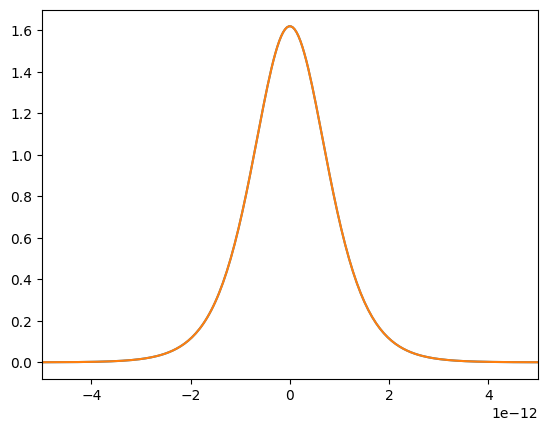

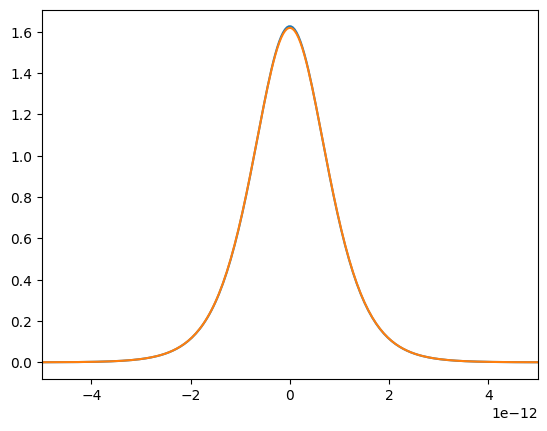

0.0
0.0005990518713082854
0.0010087551009731154
0.0012652505461256671
0.001433129005512374
0.0015510482208727036
0.0016411699175586548
0.0017154792436126806
0.0017808569566916095
0.0018413707354952653
0.0018995854526911908
0.00195719470440255
0.0020153735152874837
0.002074963708005692
0.002136580473007983
0.002200672844218991
0.002267560737195877
0.0023374587007381972
0.0024104925028145857
0.0024867116351096697
0.002566099625835298
0.0026485830869537605
0.0027340399318080645
0.0028223069605697398
0.0029131869055548866
0.003006454951174005
0.003101864713231891
0.0031991536697592495
0.0032980480507452514
0.003398267203735885
0.003499527461041987
0.0036015455426746737
0.0037040415339025423
0.0038067414779069677
0.003909379624178217
0.004011700371606725
0.00411345994127018
0.004214427809255998
0.004314387926160674
0.004413139746955445
0.004510499091729928
0.0046062988540036135
0.004700389569808858
0.004792639858340941
0.004882936743683974
0.004971185865198922
0.00505731158247774
0.00514125

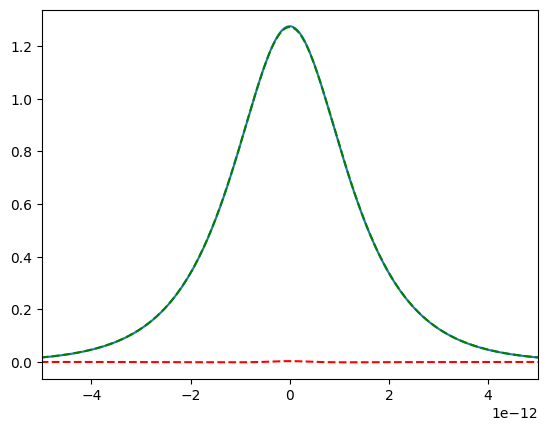

In [13]:
L2_norm = lambda x, y: np.sqrt(np.trapezoid(np.abs(y) ** 2, x))

plt.plot(t, np.abs(A[0]) ** 2)
plt.plot(t, P_0 * np.abs(u_gt(0) / N) ** 2)
plt.xlim(-5 * T_0, 5 * T_0)
plt.show()

plt.plot(t, np.abs(A[-1]) ** 2)
plt.plot(t, P_0 * np.abs(u_gt(xi_max) / N) ** 2)
plt.xlim(-5 * T_0, 5 * T_0)
plt.show()

ind = -1
_xi = z[ind] / L_D
A_ref = np.sqrt(P_0) * u_gt(_xi) / N
e = A[ind] - A_ref
plt.plot(t, np.imag(A[ind]))
plt.plot(t, np.imag(A_ref), 'g--')
plt.plot(t, np.imag(e), 'r--')
plt.xlim(-5 * T_0, 5 * T_0)

L2_norm(t, e) / L2_norm(t, A_ref), L2_norm(t, e), L2_norm(t, A_ref)


for ind, _xi in enumerate(z / L_D):
    A_gt = np.sqrt(P_0) * u_gt(_xi) / N
    e = A[ind] - A_gt
    error = L2_norm(t, e) / L2_norm(t, A_gt)
    print(error)

plt.xlim(-5 * T_0, 5 * T_0)
plt.show()

In [291]:
from NLSE import split_step_fast

beta2_sign = -1

N = 2

def nl_operator(u):
    return 1j * np.abs(u) ** 2

def diff_operator(omega):
    return 1j * beta2_sign / 2 * omega ** 2

u_gt = test_cases(N)
A_0 = u_gt(0) * np.sqrt(P_0) / N
xi = np.linspace(0, xi_max, 1000)
u = split_step_fast(u_gt(0), tau, xi, diff_operator, nl_operator)

e = u[-1] - u_gt(xi[-1])
error = L2_norm(tau, e) / L2_norm(tau, u_gt(xi[-1]))
error

np.float64(0.024201225597578743)

In [295]:
from NLSE import split_step_fast

beta2_sign = -1

N = 2

def nl_operator(u):
    return 1j * np.abs(u) ** 2

def diff_operator(omega):
    return 1j * beta2_sign / 2 * omega ** 2

def find_error(N, steps):
    u_gt = test_cases(N)
    xi = np.linspace(0, xi_max, steps)
    u = split_step_fast(u_gt(0), tau, xi, diff_operator, nl_operator)
    
    e = u[-1] - u_gt(xi[-1])
    error = L2_norm(tau, e) / L2_norm(tau, u_gt(xi[-1]))
    return error

In [297]:
find_error(1, 100)

np.float64(0.008919559791922814)

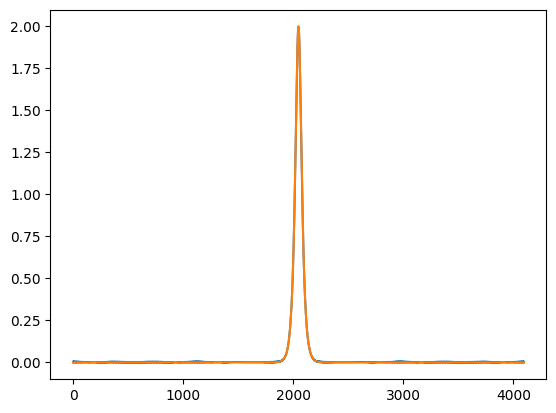

In [294]:
plt.plot(np.abs(u[-1]))
plt.plot(np.abs(u_gt(xi[-1])))